In [20]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
# from langchain_core.runnables import RunnableConfig
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, StateGraph
from typing_extensions import TypedDict, Literal
import json, random
from tqdm import tqdm
import os

from dotenv import load_dotenv
load_dotenv()


True

# Load Fold 5 Datasets

In [5]:
# Setting file paths
fold_path = os.path.join(os.path.dirname(os.getcwd()), 'data', 'pqal_fold2')
train_data = json.load(open(os.path.join(fold_path, "train_set.json")))
dev_data = json.load(open(os.path.join(fold_path, "dev_set.json")))

print(f"# Train examples: {len(train_data)}")
print(f"# Dev examples: {len(dev_data)}")


# Train examples: 450
# Dev examples: 50


# Select Few-Shot Examples from Train Set

In [44]:
# # import random

# few_shot_examples = [
#     {
#         "context": "Statins are used to treat cardiovascular disease. This study evaluates their effectiveness in older adults.",
#         "question": "Are statins effective in elderly patients for reducing heart attacks?",
#         "rationale": "The study population includes older adults and finds a statistically significant reduction in heart attacks among those taking statins.",
#         "answer": "yes"
#     },
#     {
#         "context": "A small trial looked at a new treatment for Alzheimer's disease. The results were mixed and inconclusive.",
#         "question": "Does the new treatment improve memory in Alzheimer's patients?",
#         "rationale": "While some patients improved, the sample size was small and the results were not statistically significant.",
#         "answer": "maybe"
#     },

#     {
#     "context": (
#         "Urine samples were examined by wet smear microscopy, incubated in 5% CO₂ for 1–2 days, and species-specific PCR for A. schaalii was performed. "
#         "In 5 of the 29 screened urines, A. schaalii was found only by PCR in moderate quantities. In two cases, both PCR and culture found A. schaalii with signs of infection. "
#         "The authors recommend PCR or Gram staining when cultures are negative but symptoms persist."
#     ),
#     "question": "Actinobaculum schaalii, a cause of urinary tract infections in children?",
#     "rationale": (
#         "The study shows A. schaalii was found in some urine samples, mostly via PCR, and only a few cases had both PCR and culture evidence with symptoms. "
#         "The authors suggest testing when symptoms are present but standard culture is negative, indicating possible relevance. "
#         "However, the evidence is limited and based on a small number of cases, so it is suggestive but not conclusive."
#     ),
#     "answer": "maybe"
#     },
    
#     {
#         "context": "Vitamin C supplements were tested in a randomized trial for cancer prevention. The study found no difference.",
#         "question": "Does Vitamin C prevent cancer?",
#         "rationale": "The trial showed no significant difference between the treatment and control groups, indicating no preventive effect.",
#         "answer": "no"
#     }
# ]

# Prepare a curated 6-shot prompt: 2 yes, 2 no, 2 maybe (with consistent tone and strength)
from random import sample

# Sample 2 strong examples per label from the filtered sets used earlier
few_shot_curated = (
    sample(by_label["yes"], 2) +
    sample(by_label["no"], 2) +
    sample(by_label["maybe"], 2)
)

# Shuffle for natural order
shuffle(few_shot_curated)

import pandas as pd
import IPython.display as disp
disp.display(pd.DataFrame(few_shot_curated))



,question,context,rationale,answer
0,Is HIV/STD control in Jamaica making a differe...,To assess the impact of the comprehensive HIV/...,HIV/STD control measures appear to have slowed...,yes
1,Is tumour expression of VEGF associated with v...,To determine whether there is a relationship b...,Progression of a pT3 tumour into the renal vei...,maybe
2,Does family practice at residency teaching sit...,Family medicine has aspired to train residents...,The residency training sites of the Northeaste...,yes
3,Is there any interest to perform ultrasonograp...,To evaluate the accuracy of ultrasonographic e...,Sonography has no place in the diagnosis of un...,no
4,Do somatic complaints predict subsequent sympt...,Evidence suggests substantial comorbidity betw...,Our findings suggest that somatic complaints m...,maybe
5,Delayed diagnosis of anorectal malformations: ...,Infants referred to our institution with a fin...,Delayed diagnosis of an ARM appears to be comm...,no


# Define Prompt Template

In [45]:
def build_prompt(example, few_shot):
    cot_instruction = (
        "You are a clinical research assistant. Read the study context carefully, "
        "reason step by step based on the evidence, and then answer the question with 'yes', 'no', or 'maybe'."
        "If the evidence is inconclusive, contradictory, or lacks sufficient information, answer 'maybe'"
    )
    
    prompt_text = cot_instruction + "\n\n"

    for fs in few_shot:
        prompt_text += (
            f"Context: {fs['context']}\n"
            f"Question: {fs['question']}\n"
            "Let's think step by step.\n"
            f"{fs['rationale']}\n"
            f"Answer: {fs['answer']}\n\n"
        )
    
    prompt_text += (
        f"Context: {example['context']}\n"
        f"Question: {example['question']}\n"
        "Let's think step by step.\n"
    )
    
    return prompt_text


# Add CoT output parser

In [46]:
import re

def extract_final_answer(response_text: str) -> str:
    match = re.search(r"answer\s*[:\-]?\s*(yes|no|maybe)", response_text.lower())
    if match:
        return match.group(1)
    for word in reversed(response_text.strip().lower().split()):
        if word in {"yes", "no", "maybe"}:
            return word
    return "maybe"  # conservative fallback


# Define output schema

In [47]:
# class AnswerOutput(TypedDict):
#     answer: Literal["yes", "no", "maybe"]

class AgentState(TypedDict):
    question: str
    context: str
    rationale: str  # new field for CoT
    answer: Literal["yes", "no", "maybe"]



llm = ChatOpenAI(model="gpt-4o-mini")

# prompt_node = lambda x: {"content": build_prompt(x, few_shot_examples)}
# llm_node = llm.with_structured_output(AnswerOutput)


# Define Graph Flow

In [60]:
from langgraph.graph import StateGraph

builder = StateGraph(state_schema=AgentState)


# Define the function normally
# def ask_llm(state: AgentState) -> AgentState:
#     prompt_text = build_prompt(state, few_shot_curated)
#     response = llm.invoke([HumanMessage(content=prompt_text)])
#     full_response = response.content.strip()

#     return {
#         **state,
#         "rationale": full_response,
#         "answer": extract_final_answer(full_response)
#     }

from collections import Counter

def ask_llm(state: AgentState, k: int = 5) -> AgentState:
    prompt_text = build_prompt(state, few_shot_curated)

    # Run the LLM k times and collect responses
    responses = []
    for _ in range(k):
        response = llm.invoke([HumanMessage(content=prompt_text)])
        content = response.content.strip()
        responses.append(content)

    # Extract final answers from each response
    answers = [extract_final_answer(r) for r in responses]
    vote_counts = Counter(answers)
    majority_answer = vote_counts.most_common(1)[0][0]

    return {
        **state,
        "rationale": "\n\n---\n\n".join(responses),  # optionally store all rationales
        "answer": majority_answer
    }

# Then register it with the graph
builder.add_node("ask_llm", ask_llm)
builder.set_entry_point("ask_llm")
graph = builder.compile()


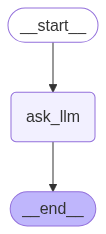

In [61]:
from IPython.display import Image

# Show graph as PNG (may be incomplete — doesn’t show conditional edges)
Image(graph.get_graph().draw_mermaid_png())

# Run Inference

In [62]:
from langchain_core.messages import HumanMessage

# Test example
sample_question = {
    "question": "Does the enteral feeding advancement affect short-term outcomes in very low birth weight infants?",
    "context": """
    Controversy exists regarding the optimal enteral feeding regimen of very low birth weight infants (VLBW). Rapid advancement of enteral feeding has been associated with an increased rate of necrotizing enterocolitis. In contrast, delaying enteral feeding may have unfavorable effects on nutrition, growth, and neurodevelopment. The aim is to compare the short-term outcomes of VLBW infants in tertiary care centers according to their enteral feeding advancement.",
            "We prospectively studied the influence of center-specific enteral feeding advancement in 1430 VLBW infants recruited from 13 tertiary neonatal intensive care units in Germany on short-term outcome parameters. The centers were post hoc stratified to \"rapid advancement to full enteral feeds\" (median duration of advancement to full enteral feeds<or =12.5 days; 6 centers), that is, rapid advancement (RA), or \"slow advancement to full enteral feeds\" (median duration of advancement to full enteral feeds>12.5 days; 7 centers), that is, slow advancement (SA).",
            "VLBW infants born in centers with SA (n = 713) had a significantly higher rate of sepsis compared with VLBW infants born in centers with RA (n = 717), which was particularly evident for late-onset sepsis (14.0% vs 20.4%; P = 0.002). Furthermore, more central venous lines (48.6% vs 31.1%, P<0.001) and antibiotics (92.4% vs 77.7%, P<0.001) were used in centers with SA."""
,
    "answer": None  # Include this if `answer` is part of your state schema
}


result = graph.invoke(sample_question)
print(result)


{'question': 'Does the enteral feeding advancement affect short-term outcomes in very low birth weight infants?', 'context': '\n    Controversy exists regarding the optimal enteral feeding regimen of very low birth weight infants (VLBW). Rapid advancement of enteral feeding has been associated with an increased rate of necrotizing enterocolitis. In contrast, delaying enteral feeding may have unfavorable effects on nutrition, growth, and neurodevelopment. The aim is to compare the short-term outcomes of VLBW infants in tertiary care centers according to their enteral feeding advancement.",\n            "We prospectively studied the influence of center-specific enteral feeding advancement in 1430 VLBW infants recruited from 13 tertiary neonatal intensive care units in Germany on short-term outcome parameters. The centers were post hoc stratified to "rapid advancement to full enteral feeds" (median duration of advancement to full enteral feeds<or =12.5 days; 6 centers), that is, rapid adv

In [63]:
print(result['rationale'])

The study indicates that enteral feeding advancement has a significant impact on short-term outcomes for very low birth weight (VLBW) infants. Specifically, those in centers with a slow advancement to full enteral feeds had a higher incidence of sepsis compared to those in centers with a rapid advancement regimen. The data suggest that rapid advancement is linked to better outcomes, reducing the risk of complications like late-onset sepsis. Therefore, there is evidence to support that the method of enteral feeding advancement does affect the short-term health outcomes for these infants.

Answer: yes

---

The evidence indicates that VLBW infants who were born in centers with a slow advancement (SA) to full enteral feeds had worse short-term outcomes, including a higher rate of sepsis, particularly late-onset sepsis, and more frequent use of central venous lines and antibiotics compared to those in centers with rapid advancement (RA). This suggests that the rate at which enteral feeding

yes


# Run Agent on Dev Set

In [65]:
predictions = {}
for pmid, item in tqdm(dev_data.items()):
    q = item["QUESTION"]
    context = "\n".join(item["CONTEXTS"])
    # prompt = build_prompt(q, context, few_shot=few_shot_examples)
    response = graph.invoke({
        "question": q,
        "context": context,
        "rationale":None,
        "answer": None
    })["answer"]
    # if response not in {"yes", "no", "maybe"}:
    #     response = "maybe"
    predictions[pmid] = response


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [06:38<00:00,  7.97s/it]


In [66]:
output_path = os.path.join(os.path.dirname(os.getcwd()), 'outputs', 'fold2_predictions_chain_cot_majority.json')
os.makedirs(os.path.dirname(output_path), exist_ok=True)
# output_path.parent.mkdir(exist_ok=True)
with open(output_path, "w") as f:
    json.dump(predictions, f, indent=2)
print("Saved predictions to", output_path)


Saved predictions to E:\000UC_Berkeley\Others\Job Application\Clinical Literature Agent\pubmed-qa-llm\outputs\fold2_predictions_chain_cot_majority.json


# Evaluating results

In [67]:
from sklearn.metrics import classification_report, accuracy_score

# Load ground truth (dev set from Fold 5)
ground_truth = {k: v["final_decision"] for k, v in dev_data.items()}
human_reasoning_free = {k: v["reasoning_free_pred"] for k, v in dev_data.items()}
human_reasoning_required = {k: v["reasoning_required_pred"] for k, v in dev_data.items()}

# Load your model predictions
with open(output_path) as f:
    predictions = json.load(f)

# Collect model and human predictions
y_true = []
y_pred_model = []
y_pred_human_free = []
y_pred_human_required = []

for pmid, true_label in ground_truth.items():
    if pmid in predictions:
        y_true.append(true_label.lower())
        y_pred_model.append(predictions[pmid].lower())
        y_pred_human_free.append(human_reasoning_free[pmid].lower())
        y_pred_human_required.append(human_reasoning_required[pmid].lower())
    else:
        print(f"Missing prediction for PMID: {pmid}")

# Evaluate
print("✅ Model Accuracy:", accuracy_score(y_true, y_pred_model))
print("✅ Model Classification Report:")
print(classification_report(y_true, y_pred_model, labels=["yes", "no", "maybe"]))

print("\n🧠 Reasoning-Free Human Accuracy:", accuracy_score(y_true, y_pred_human_free))
print("🧠 Reasoning-Free Human Report:")
print(classification_report(y_true, y_pred_human_free, labels=["yes", "no", "maybe"]))

print("\n🧠 Reasoning-Required Human Accuracy:", accuracy_score(y_true, y_pred_human_required))
print("🧠 Reasoning-Required Human Report:")
print(classification_report(y_true, y_pred_human_required, labels=["yes", "no", "maybe"]))


✅ Model Accuracy: 0.78
✅ Model Classification Report:
              precision    recall  f1-score   support

         yes       0.92      0.82      0.87        28
          no       0.93      0.82      0.88        17
       maybe       0.20      0.40      0.27         5

    accuracy                           0.78        50
   macro avg       0.68      0.68      0.67        50
weighted avg       0.85      0.78      0.81        50


🧠 Reasoning-Free Human Accuracy: 0.98
🧠 Reasoning-Free Human Report:
              precision    recall  f1-score   support

         yes       1.00      0.96      0.98        28
          no       1.00      1.00      1.00        17
       maybe       0.83      1.00      0.91         5

    accuracy                           0.98        50
   macro avg       0.94      0.99      0.96        50
weighted avg       0.98      0.98      0.98        50


🧠 Reasoning-Required Human Accuracy: 0.74
🧠 Reasoning-Required Human Report:
              precision    recall  f